<a href="https://colab.research.google.com/github/pranathigadhanki-alt/stock-prediction-ml-/blob/main/stock_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_2086/2123081504.py:38: FutureWarning: YF.download() has changed argument auto_adjust default to True
  temp = yf.download(ticker, period="1y")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2086/2123081504.py:38: FutureWarning: YF.download() has changed argument auto_adjust default to True
  temp = yf.download(ticker, period="1y")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2086/2123081504.py:38: FutureWarning: YF.download() has changed argument auto_adjust default to True
  temp = yf.download(ticker, period="1y")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2086/2123081504.py:38: FutureWarning: YF.download() has changed argument auto_adjust default to True
  temp = yf.download(ticker, period="1y")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2086/2123081504.py:38: FutureWarning: YF.download() has changed argument auto

Rows BEFORE features: 2500
Columns: Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker'], dtype='object')
Rows AFTER cleaning: 2300
Train size: 1840
Test size: 460
Model trained successfully!

Evaluation Results:
MAE: 0.019785529371712223
MSE: 0.0006857541147784816
   Actual_Return  Predicted_Return Actual_Direction Predicted_Direction
0      -0.002460         -0.000812             DOWN                DOWN
1       0.031002          0.000622               UP                  UP
2       0.002648         -0.001754               UP                DOWN
3      -0.006135         -0.004561             DOWN                DOWN
4       0.054436          0.014255               UP                  UP
5       0.056341          0.021602               UP                  UP
6       0.041638          0.012459               UP                  UP
7      -0.003768         -0.003335             DOWN                DOWN
8       0.004228         -0.010377               UP                DOWN


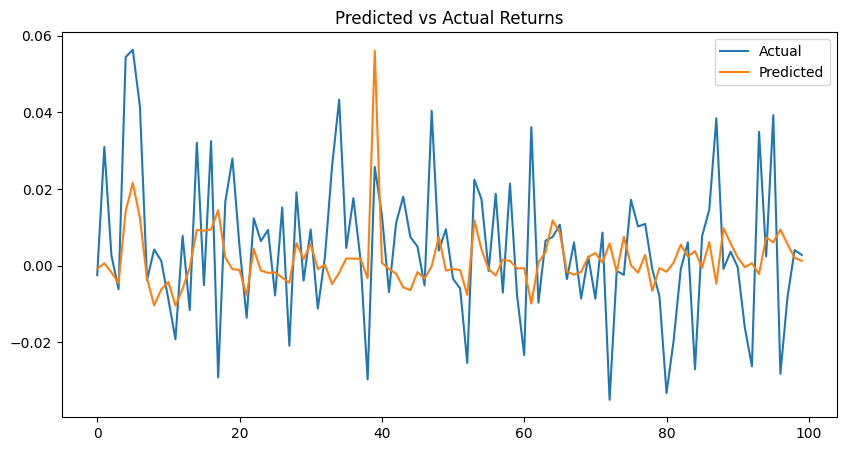

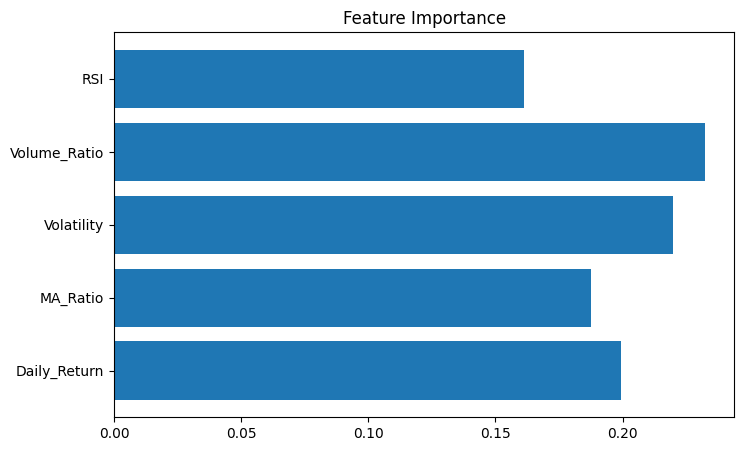


Project complete ✅
⚠️ Not financial advice


In [36]:
# ============================================================
# STOCK RETURN PREDICTION (FINAL GUARANTEED WORKING VERSION)
# ============================================================

# -------------------------------
# INSTALL (Colab only)
# -------------------------------
!pip install yfinance scikit-learn pandas matplotlib seaborn

# -------------------------------
# IMPORTS
# -------------------------------
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -------------------------------
# SETTINGS
# -------------------------------
TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA",
           "NVDA", "META", "JPM", "NFLX", "AMD"]

TEST_SIZE = 0.2
RANDOM_STATE = 42

# -------------------------------
# DOWNLOAD DATA (FIXED)
# -------------------------------
all_data = []

for ticker in TICKERS:
    temp = yf.download(ticker, period="1y")

    # 🔥 FORCE FLATTEN COLUMNS (CRITICAL FIX)
    temp.columns = [col[0] if isinstance(col, tuple) else col for col in temp.columns]

    # Reset index
    temp = temp.reset_index()

    # Add ticker label
    temp["Ticker"] = ticker

    all_data.append(temp)

# Combine all stocks
df = pd.concat(all_data, ignore_index=True)

# Sort properly
df = df.sort_values(["Ticker", "Date"])

print("Rows BEFORE features:", len(df))
print("Columns:", df.columns)


# -------------------------------
# FEATURE ENGINEERING (FIXED)
# -------------------------------

# Daily Return (FIXED)
df["Daily_Return"] = df.groupby("Ticker")["Close"].transform(
    lambda x: x.pct_change()
)

# Moving averages
df["MA5"] = df.groupby("Ticker")["Close"].transform(lambda x: x.rolling(5).mean())
df["MA20"] = df.groupby("Ticker")["Close"].transform(lambda x: x.rolling(20).mean())

df["MA_Ratio"] = df["MA5"] / df["MA20"]

# Volatility
df["Volatility"] = df.groupby("Ticker")["Daily_Return"].transform(
    lambda x: x.rolling(5).std()
)

# Volume ratio
df["Volume_Ratio"] = df["Volume"] / df.groupby("Ticker")["Volume"].transform(
    lambda x: x.rolling(20).mean()
)

# RSI (SAFE GROUPED VERSION)
def compute_rsi(series):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()

    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df["RSI"] = df.groupby("Ticker")["Close"].transform(compute_rsi)

# Target (next day return)
df["Target"] = df.groupby("Ticker")["Close"].transform(
    lambda x: x.pct_change().shift(-1)
)

# -------------------------------
# CLEAN DATA
# -------------------------------
df = df.dropna()

print("Rows AFTER cleaning:", len(df))


# -------------------------------
# PREPARE DATA
# -------------------------------
FEATURES = ["Daily_Return", "MA_Ratio", "Volatility", "Volume_Ratio", "RSI"]

X = df[FEATURES]
y = df["Target"]


# -------------------------------
# TRAIN / TEST SPLIT (TIME SERIES SAFE)
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, shuffle=False
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


# -------------------------------
# SCALE FEATURES
# -------------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# -------------------------------
# TRAIN MODEL
# -------------------------------
model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)

model.fit(X_train, y_train)

print("Model trained successfully!")


# -------------------------------
# PREDICT
# -------------------------------
y_pred = model.predict(X_test)


# -------------------------------
# EVALUATE
# -------------------------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("\nEvaluation Results:")
print("MAE:", mae)
print("MSE:", mse)

# -------------------------------
# SHOW UP/DOWN PREDICTIONS
# -------------------------------

results = pd.DataFrame({
    "Actual_Return": y_test.values,
    "Predicted_Return": y_pred
})

# Convert to direction
results["Actual_Direction"] = results["Actual_Return"].apply(lambda x: "UP" if x > 0 else "DOWN")
results["Predicted_Direction"] = results["Predicted_Return"].apply(lambda x: "UP" if x > 0 else "DOWN")

print(results.head(10))

# -------------------------------
# VISUALIZATION
# -------------------------------
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")
plt.legend()
plt.title("Predicted vs Actual Returns")
plt.show()


# -------------------------------
# FEATURE IMPORTANCE
# -------------------------------
importances = model.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(FEATURES, importances)
plt.title("Feature Importance")
plt.show()


# -------------------------------
# DONE
# -------------------------------
print("\nProject complete ✅")
print("⚠️ Not financial advice")